In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os


import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep', style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [2]:
# Let's get organized:
# pickle structure - 
# averagedS_dynamics 

probList = np.linspace(0,1,21).round(2)
rateList1 = [1e-05, 1e-03, 1e-01, 1e+01]
rateList2 = [0.3, 1, 3]
NList=[4, 6, 8, 10]

t_total = 200
dt=5
steps = int(t_total/dt)
rateList = np.logspace(-5,1,4) 

In [3]:
avgedS_dynamics_0 = {}
avgedS_steady_0 = {}

for rate in rateList1:
    
    avgedS_dynamics_0[rate] = {}
    avgedS_steady_0[rate] = {}
    
    for prob in probList:
        
        avgedS_dynamics_0[rate][prob] = {}
        avgedS_steady_0[rate][prob] = {}
                
        with open("RC_avged/avgedS_dynamics_0_p=" + str(prob) + ".pkl", 'rb') as f:
            temp = pickle.load(f)
            
        # N=10 dynamics
        avgedS_dynamics_0[rate][prob] = temp[rate][prob][10]
        

In [4]:
avgedS_dynamics_1 = {}
avgedS_steady_1 = {}

for rate in rateList1:
    
    avgedS_dynamics_1[rate] = {}
    avgedS_steady_1[rate] = {}
    
    for prob in probList:
        
        avgedS_dynamics_1[rate][prob] = {}
        avgedS_steady_1[rate][prob] = {}
                
        with open("RC_avged/avgedS_dynamics_1_p=" + str(prob) + ".pkl", 'rb') as f:
            temp = pickle.load(f)
            
        avgedS_steady_1[rate][prob] = np.zeros(4)

            
        # N=10 dynamics
        avgedS_dynamics_1[rate][prob] = temp[rate][prob][10]
        for (n,N) in enumerate(NList): 
            avgedS_steady_1[rate][prob][n] = np.average(temp[rate][prob][N][steps//2:])
            #print('r=', rate, ' prob=',prob, ' N=', N, 'avg = ', np.average(temp[rate][prob][N][steps//2:]), n)

        

for rate in rateList2:
    
    avgedS_dynamics_1[rate] = {}
    avgedS_steady_1[rate] = {}
    
    for prob in probList:
        
        avgedS_dynamics_1[rate][prob] = {}
        avgedS_steady_1[rate][prob] = {}
                
        with open("RC_avged/avgedS_dynamics_1_extra_rs_p=" + str(prob) + ".pkl", 'rb') as f:
            temp = pickle.load(f)
            
        # N=10 dynamics
        avgedS_dynamics_1[rate][prob] = temp[rate][prob][10]
        
        avgedS_steady_1[rate][prob] = np.zeros(4)
        
        for (n,N) in enumerate(NList): 
            avgedS_steady_1[rate][prob][n] = np.average(temp[rate][prob][N][steps//2:])
            #print('r=', rate, ' prob=',prob, ' N=', N, 'avg = ', np.average(temp[rate][prob][N][steps//2:]), n)
        #print(avgedS_steady_1[rate][prob])
    


In [132]:
# Let's rename all the files first:
fileList = os.listdir("RC_raw/")
 
for prob in probList:
    for N in NList:
        if os.path.isfile("RC_raw/S1_S_minus_p=" + str(prob) + "_r=10_N=" + str(N) + ".out"):
            os.rename("RC_raw/S1_S_minus_p=" + str(prob) + "_r=10_N=" + str(N) + ".out",
                     "RC_raw/S1_S_minus_p=" + str(prob) + "_r=10.0_N=" + str(N) + ".out")
        
        if os.path.isfile("RC_raw/S1_S_minus_p=" + str(prob) + "_r=1_N=" + str(N) + ".out"):
            os.rename("RC_raw/S1_S_minus_p=" + str(prob) + "_r=1_N=" + str(N) + ".out",
                     "RC_raw/S1_S_minus_p=" + str(prob) + "_r=1.0_N=" + str(N) + ".out")

        if os.path.isfile("RC_raw/I_S_minus_p=" + str(prob) + "_r=10_N=" + str(N) + ".out"):
            os.rename("RC_raw/I_S_minus_p=" + str(prob) + "_r=10_N=" + str(N) + ".out",
                     "RC_raw/I_S_minus_p=" + str(prob) + "_r=10.0_N=" + str(N) + ".out")
        
        if os.path.isfile("RC_raw/I_S_minus_p=" + str(prob) + "_r=1_N=" + str(N) + ".out"):
            os.rename("RC_raw/I_S_minus_p=" + str(prob) + "_r=1_N=" + str(N) + ".out",
                     "RC_raw/I_S_minus_p=" + str(prob) + "_r=1.0_N=" + str(N) + ".out")






In [7]:
rateList = np.logspace(-4,3,8)
probList = np.linspace(0,1,21).round(2)


avgedS_dynamics_1 = {}
avgedS_steady_1 = {}



for rate in rateList:
    avgedS_dynamics_1[rate] = {}
    avgedS_steady_1[rate] = {}


    for prob in probList: 

        avgedS_steady_1[rate][prob] = np.zeros(4)

        for (n,N) in enumerate(NList): 
            
            if os.path.isfile("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
                temp = np.array(np.loadtxt("RC_raw/S_minus/S1_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
                #print(np.average(temp,axis=0).shape)
                avgedS_dynamics_1[rate][prob] = np.average(temp,axis=0)

                steps = len(temp)//2

                avgedS_steady_1[rate][prob][n] = np.average(temp[steps:])
                
            else:
                print('missing rate=',rate,', prob=', prob)

                #"S1_S_minus_p=0.75_r=0.01_N=10.out"



missing rate= 0.0001 , prob= 0.05
missing rate= 0.0001 , prob= 0.15
missing rate= 0.001 , prob= 0.05
missing rate= 0.001 , prob= 0.15
missing rate= 0.01 , prob= 0.05
missing rate= 0.01 , prob= 0.15
missing rate= 0.1 , prob= 0.05
missing rate= 0.1 , prob= 0.15
missing rate= 1.0 , prob= 0.05
missing rate= 1.0 , prob= 0.15
missing rate= 10.0 , prob= 0.05
missing rate= 100.0 , prob= 0.05
missing rate= 1000.0 , prob= 0.15
missing rate= 1000.0 , prob= 0.6
missing rate= 1000.0 , prob= 0.6


In [158]:
avgedS_steady_1[0.01]

{0.0: array([0., 0., 0., 0.]),
 0.05: array([2.2318165 , 3.22301412, 4.12608163, 0.        ]),
 0.1: array([1.74652865, 2.68749984, 3.38834833, 0.        ]),
 0.15: array([1.51442404, 2.23732929, 2.80053872, 0.        ]),
 0.2: array([1.23646951, 1.7665749 , 2.20260505, 2.5480238 ]),
 0.25: array([1.01716695, 1.48730493, 1.83273304, 2.10070834]),
 0.3: array([0.86233453, 1.14157839, 1.4592869 , 1.67521917]),
 0.35: array([0.67871221, 0.98860332, 1.19967195, 1.37154833]),
 0.4: array([0.57472695, 0.8122989 , 1.00302448, 1.13453349]),
 0.45: array([0.47450037, 0.62856583, 0.7383602 , 0.88953333]),
 0.5: array([0.40165174, 0.51060628, 0.594854  , 0.74324435]),
 0.55: array([0.31887549, 0.43422784, 0.49521338, 0.57305149]),
 0.6: array([0.27228111, 0.33053452, 0.39535862, 0.4610506 ]),
 0.65: array([0.20122001, 0.2560661 , 0.3239885 , 0.35243811]),
 0.7: array([0.1669699 , 0.20518519, 0.25579709, 0.27095321]),
 0.75: array([0.12115443, 0.15226266, 0.18431541, 0.21643177]),
 0.8: array([0.0

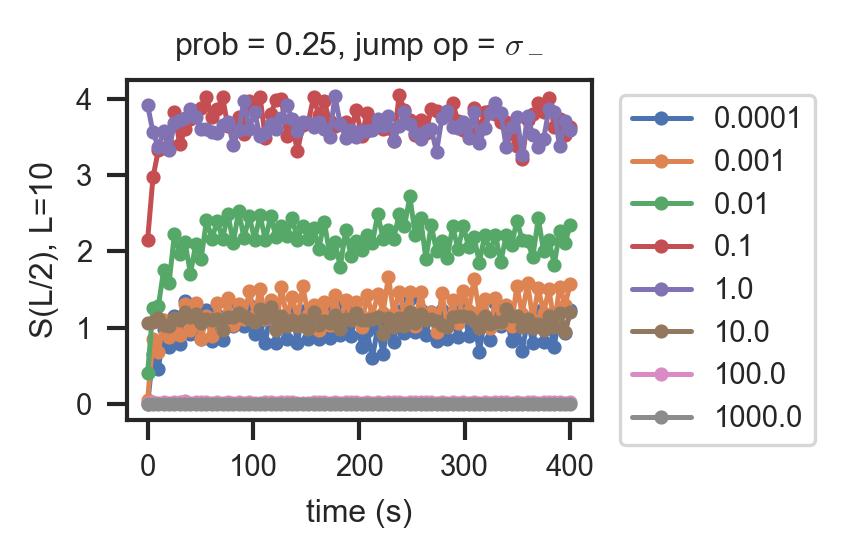

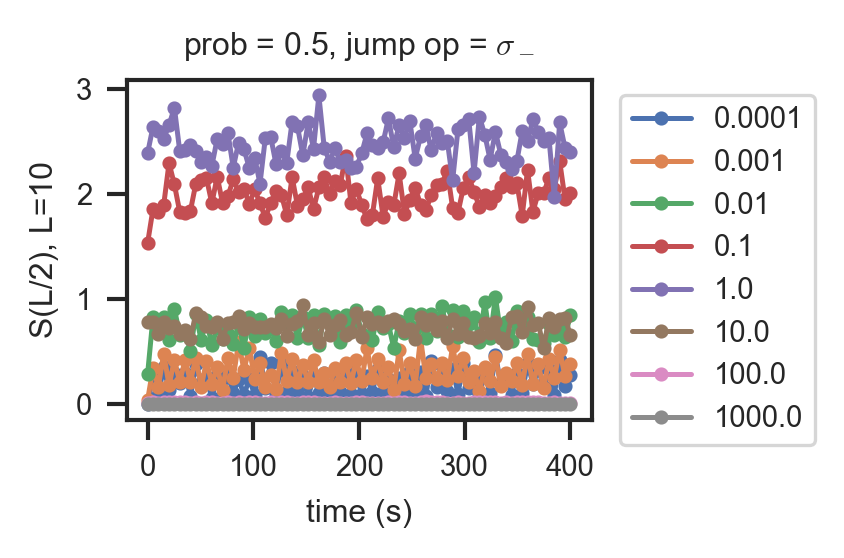

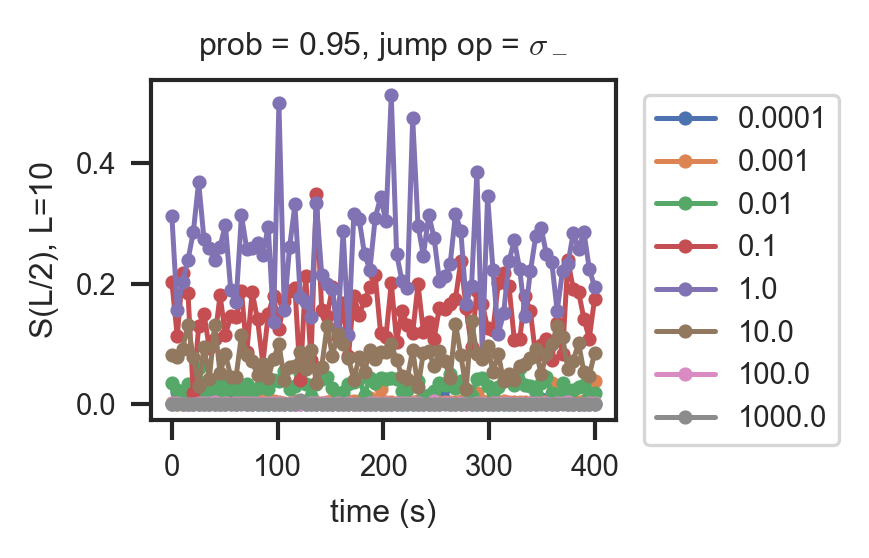

In [8]:
rateList = np.logspace(-4,3,8)
t_total = 400
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

plt.figure()
for rates in rateList:
    plt.plot(duration, avgedS_dynamics_1[rates][0.25],'.-')

plt.xlabel('time (s)') 
plt.ylabel('S(L/2), L=10')
plt.title(r'prob = ' + str(0.25) + ', jump op = $\sigma_-$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )



plt.figure()
for rates in rateList:
    plt.plot(duration, avgedS_dynamics_1[rates][0.5],'.-')

plt.xlabel('time (s)') 
plt.ylabel('S(L/2), L=10')
plt.title(r'prob = ' + str(0.5) + ', jump op = $\sigma_-$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )


plt.figure()
for rates in rateList:
    plt.plot(duration, avgedS_dynamics_1[rates][0.95],'.-')

plt.xlabel('time (s)') 
plt.ylabel('S(L/2), L=10')
plt.title(r'prob = ' + str(0.95) + ', jump op = $\sigma_-$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )



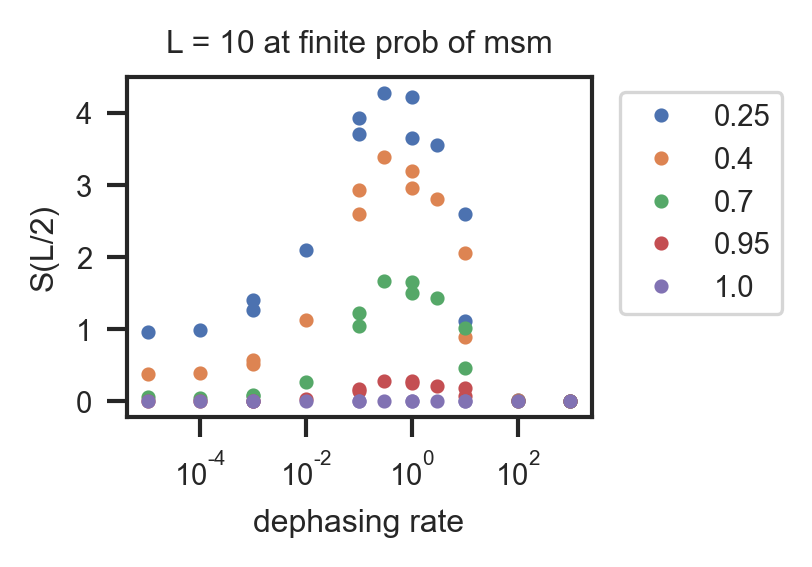

In [95]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm
rateList = rateList1 + rateList2 +rateList3
#rateList = rateList3

#rateList = np.sort(np.array(rateList).astype(float))

prob = 0.1
probTempList = [0.25, 0.4, 0.7, 0.95, 1.0]

plt.figure()
for prob in probTempList:
    SinRate = np.zeros(len(rateList))
    for (r,rate) in enumerate(rateList):
        SinRate[r] = avgedS_steady_1[rate][prob][-1]

    plt.semilogx(np.array(rateList).astype(float), SinRate,'.')
    plt.xlabel('dephasing rate')
    plt.ylabel('S(L/2)')
plt.title('L = 10 at finite prob of msm')
plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )



In [161]:
rateList

array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])

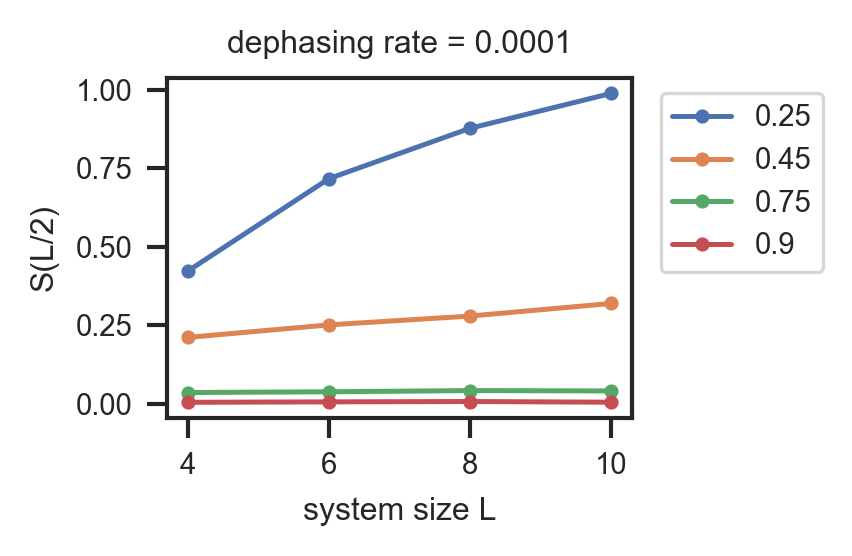

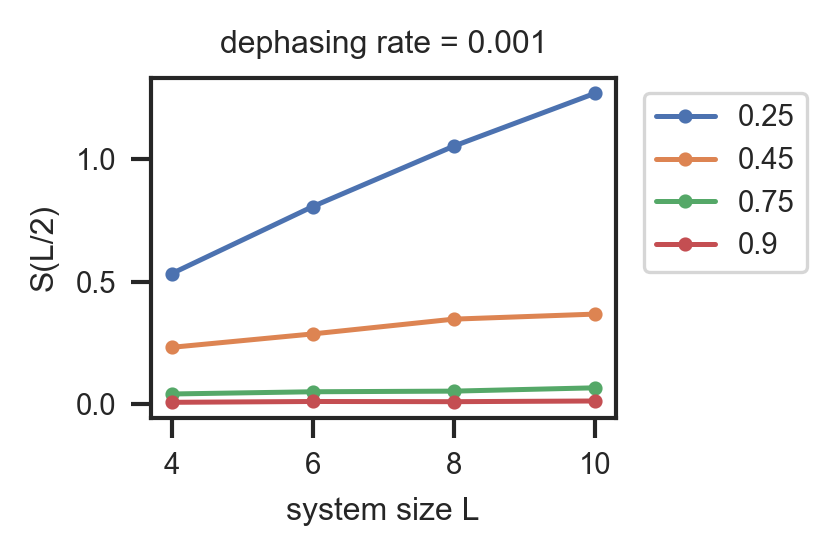

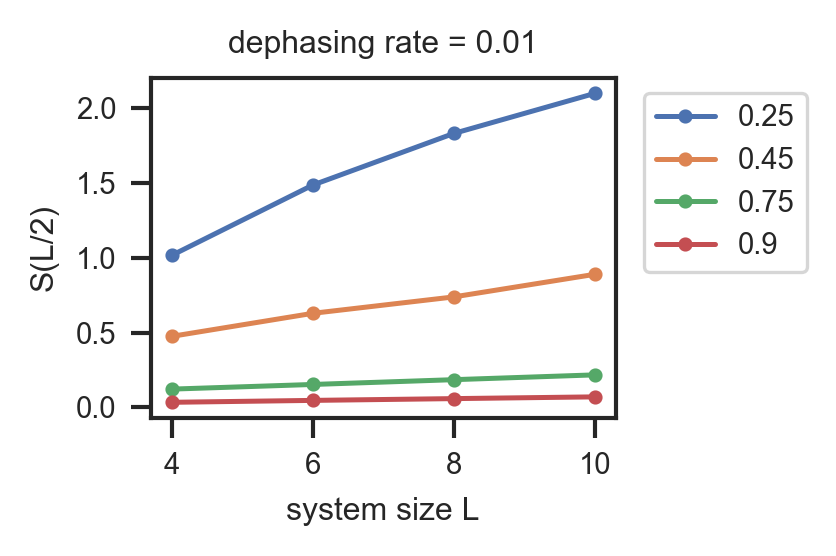

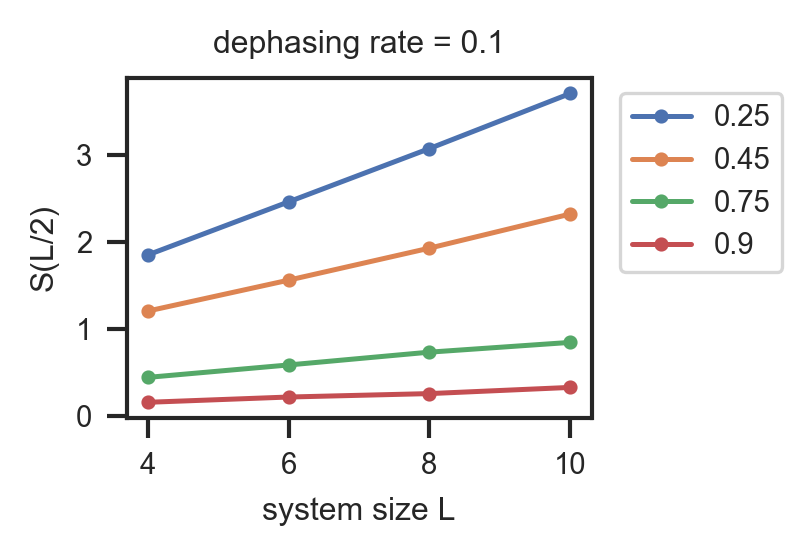

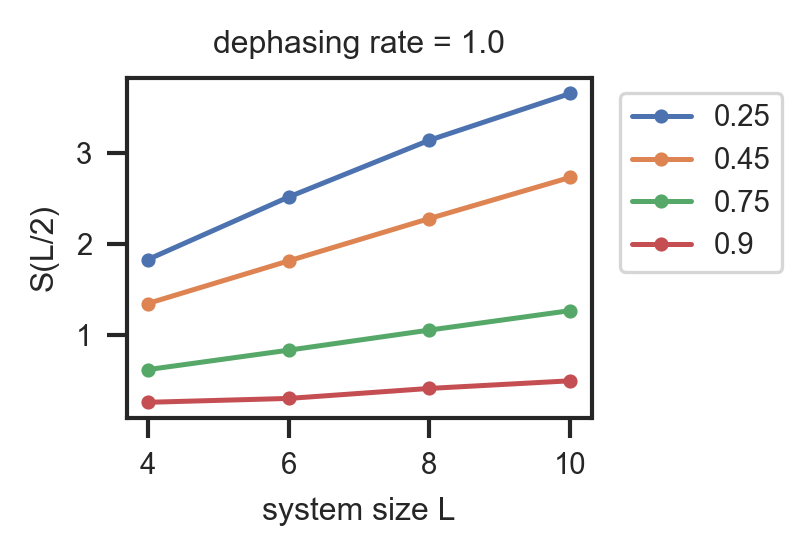

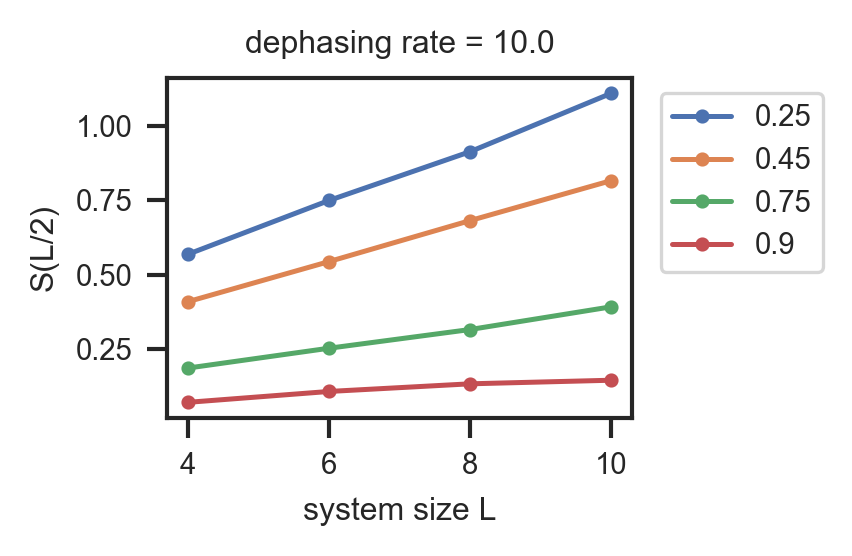

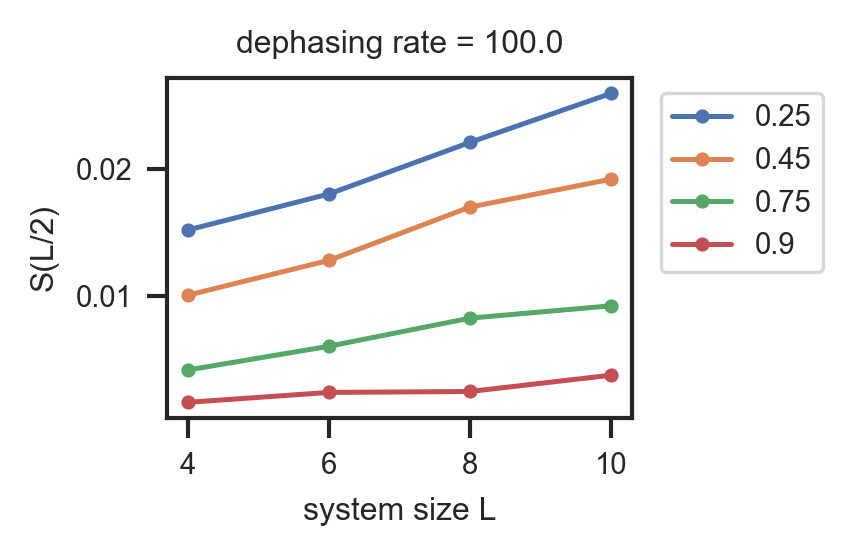

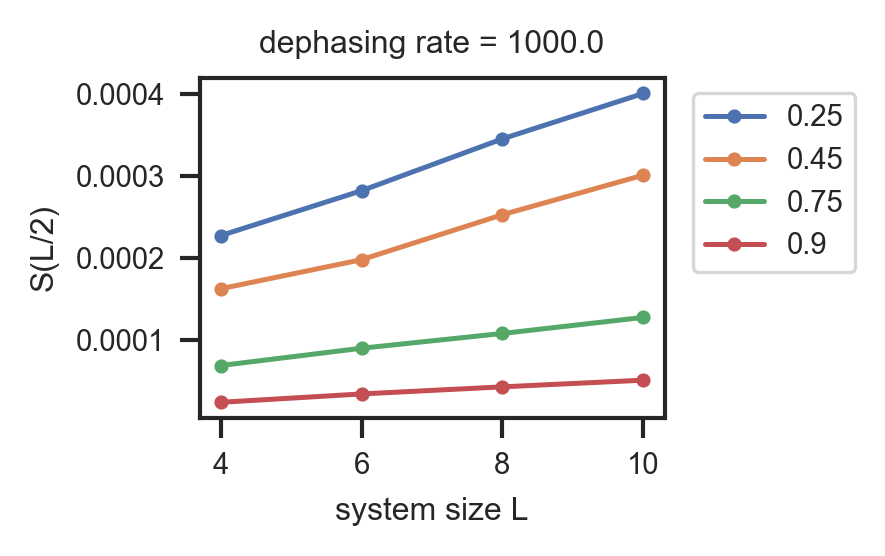

In [160]:
probList = [0.25, 0.45, .75, .9]

for rate in rateList:
    plt.figure()
    for prob in probList:
        plt.plot(np.array(NList), avgedS_steady_1[rate][prob],'.-')
        plt.xlabel('system size L')
        plt.ylabel('S(L/2)')
        plt.title('dephasing rate = ' + str(rate))
        plt.legend(probList,bbox_to_anchor= (1.03, 1))
   

[4, 6, 8, 10] 1000.0 1.0


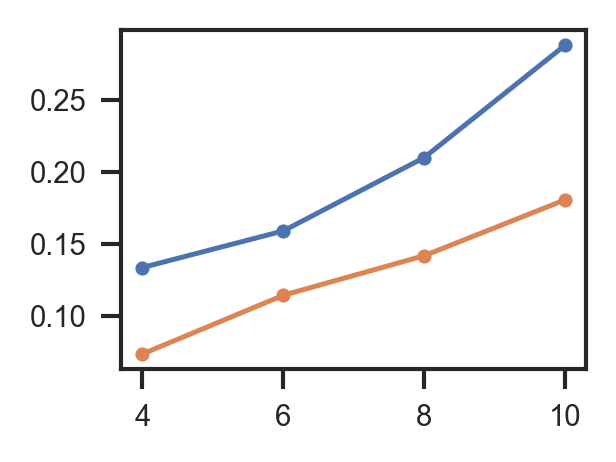

In [92]:
plt.plot(np.array(NList), avgedS_steady_1[1][.95],'.-')

plt.plot(np.array(NList), avgedS_steady_1[3][.95],'.-')

plt.plot(np.array(NList), avgedS_steady_1[10][.95],'.-')

print(NList, rate, prob)

What is S(L/2) at finite prob Msm as a function of dephasing rate? CHECKED! 

Can there be a jump operator that gives area law -  NOT SURE YET. something that effectively stop the flow of information from flowing?

at weak Gamma, t << Gamma^-1 what is the S dynamics? I see. Maybe one can impose a check at Gamma^-1/2?

purification dynamics? - CHECK FILE: Msm + dephasing (purity).ipynb

In [167]:
rateList = np.logspace(-4,3,8)
probList = np.linspace(0,1,21).round(2)

avgedMI_dynamics_1 = {}
avgedMI_steady_1 = {}

for rate in rateList:
    avgedMI_dynamics_1[rate] = {}
    avgedMI_steady_1[rate] = {}

    for prob in probList: 
        avgedMI_steady_1[rate][prob] = np.zeros(4)

        
        for (n,N) in enumerate(NList): 
            
            if os.path.isfile("RC_raw/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
                temp = np.array(np.loadtxt("RC_raw/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
                #print(np.average(temp,axis=0).shape)
                avgedMI_dynamics_1[rate][prob] = np.average(temp,axis=0)
                
                steps = len(temp)//2

                avgedMI_steady_1[rate][prob][n] = np.average(temp[steps:])
            
            #"S1_S_minus_p=0.75_r=0.01_N=10.out"
            else:
                print('missing rate=',rate,', prob=', prob)

                #"S1_S_minus_p=0.75_r=0.01_N=10.out"



missing rate= 0.0001 , prob= 0.0
missing rate= 0.0001 , prob= 0.0
missing rate= 0.0001 , prob= 0.0
missing rate= 0.0001 , prob= 0.0
missing rate= 0.0001 , prob= 0.05
missing rate= 0.0001 , prob= 0.1
missing rate= 0.0001 , prob= 0.15
missing rate= 0.001 , prob= 0.0
missing rate= 0.001 , prob= 0.0
missing rate= 0.001 , prob= 0.0
missing rate= 0.001 , prob= 0.0
missing rate= 0.001 , prob= 0.05
missing rate= 0.001 , prob= 0.1
missing rate= 0.001 , prob= 0.15
missing rate= 0.01 , prob= 0.0
missing rate= 0.01 , prob= 0.0
missing rate= 0.01 , prob= 0.0
missing rate= 0.01 , prob= 0.0
missing rate= 0.01 , prob= 0.05
missing rate= 0.01 , prob= 0.1
missing rate= 0.01 , prob= 0.15
missing rate= 0.1 , prob= 0.0
missing rate= 0.1 , prob= 0.0
missing rate= 0.1 , prob= 0.0
missing rate= 0.1 , prob= 0.0
missing rate= 0.1 , prob= 0.05
missing rate= 0.1 , prob= 0.1
missing rate= 0.1 , prob= 0.15
missing rate= 1.0 , prob= 0.0
missing rate= 1.0 , prob= 0.0
missing rate= 1.0 , prob= 0.0
missing rate= 1.0 , 

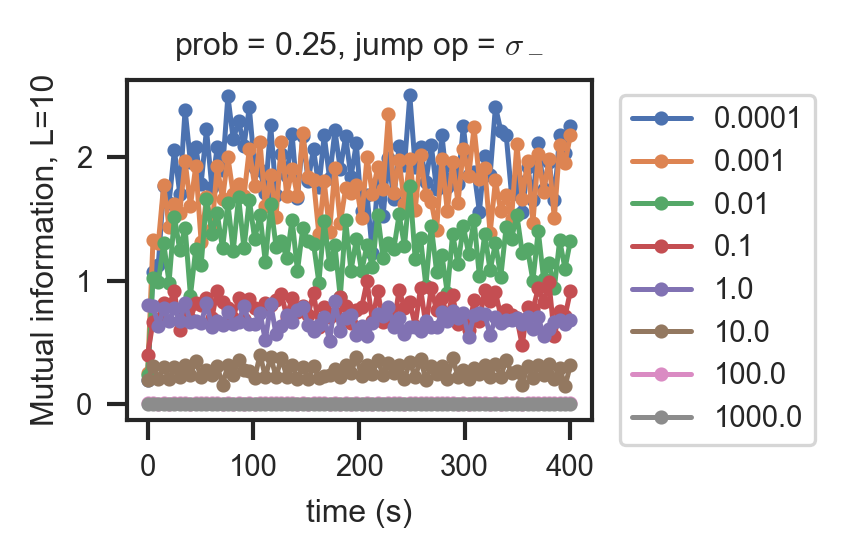

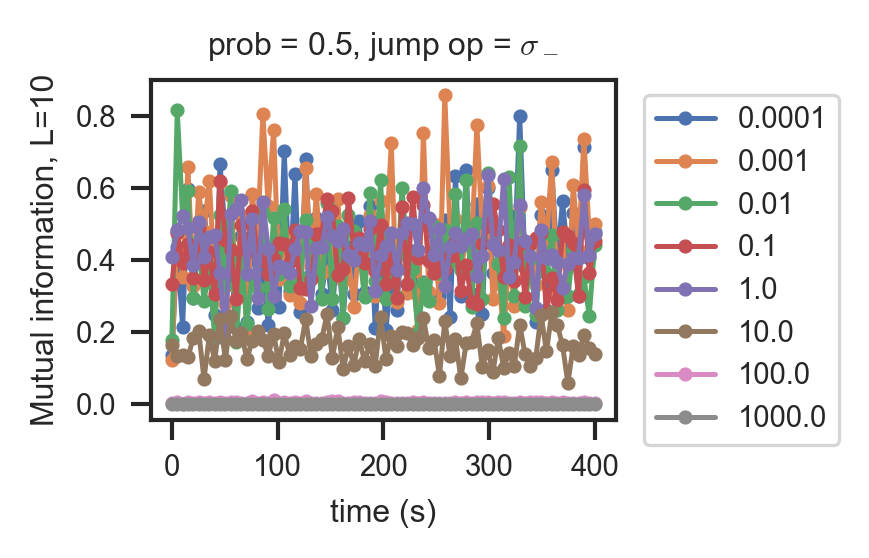

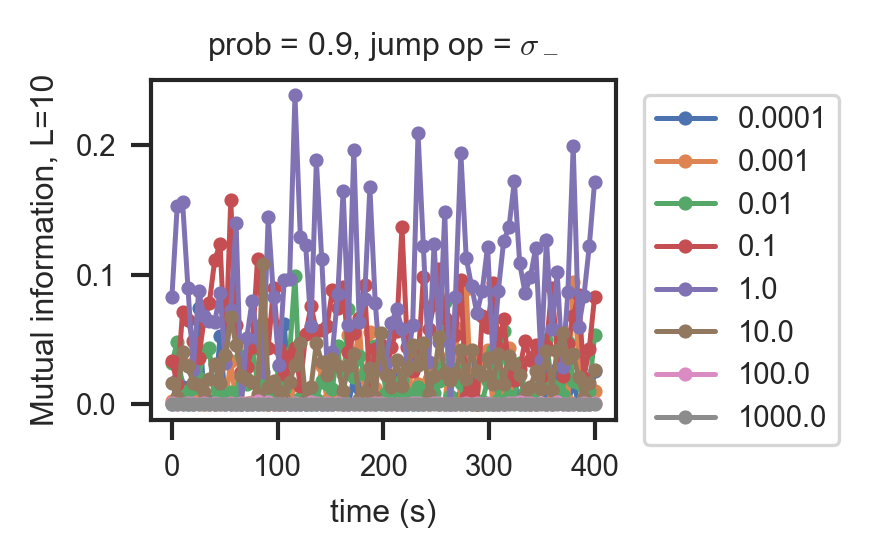

In [168]:
#rateList = np.sort(np.array(rateList))

t_total = 400
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

plt.figure()
for rates in rateList:
    plt.plot(duration, avgedMI_dynamics_1[rates][0.25],'.-')

plt.xlabel('time (s)') 
plt.ylabel('Mutual information, L=10')
plt.title(r'prob = 0.25, jump op = $\sigma_-$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )

plt.figure()
for rates in rateList:
    plt.plot(duration, avgedMI_dynamics_1[rates][0.5],'.-')

plt.xlabel('time (s)') 
plt.ylabel('Mutual information, L=10')
plt.title(r'prob = 0.5, jump op = $\sigma_-$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )



plt.figure()
for rates in rateList:
    plt.plot(duration, avgedMI_dynamics_1[rates][0.9],'.-')

plt.xlabel('time (s)') 
plt.ylabel('Mutual information, L=10')
plt.title(r'prob = 0.9, jump op = $\sigma_-$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )



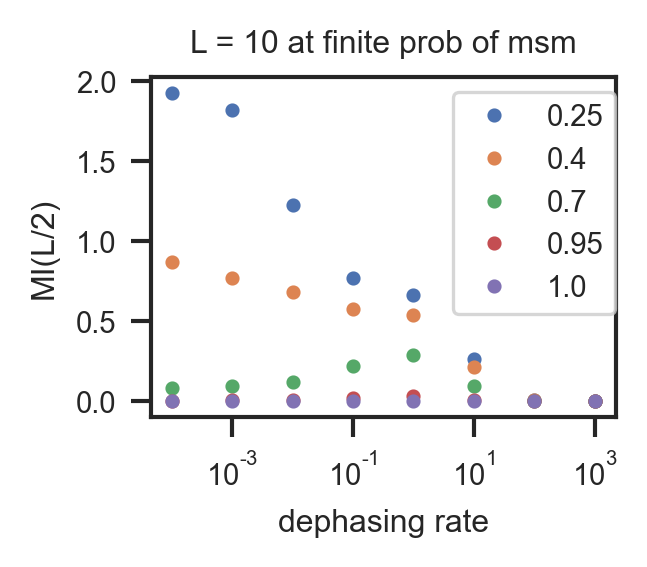

In [169]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm

probTempList = [0.25, 0.4, 0.7, 0.95, 1.0]

plt.figure()
for prob in probTempList:
    MIinRate = np.zeros(len(rateList))
    for (r,rate) in enumerate(rateList):
        MIinRate[r] = np.average(avgedMI_dynamics_1[rate][prob][-20:])

    plt.semilogx(np.array(rateList).astype(float), MIinRate,'.')
    plt.xlabel('dephasing rate')
    plt.ylabel('MI(L/2)')
plt.title('L = 10 at finite prob of msm')
plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )



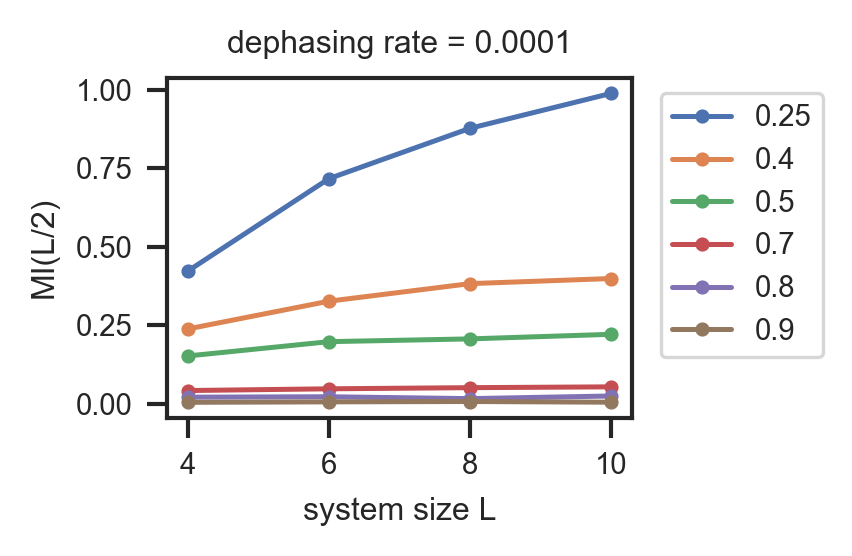

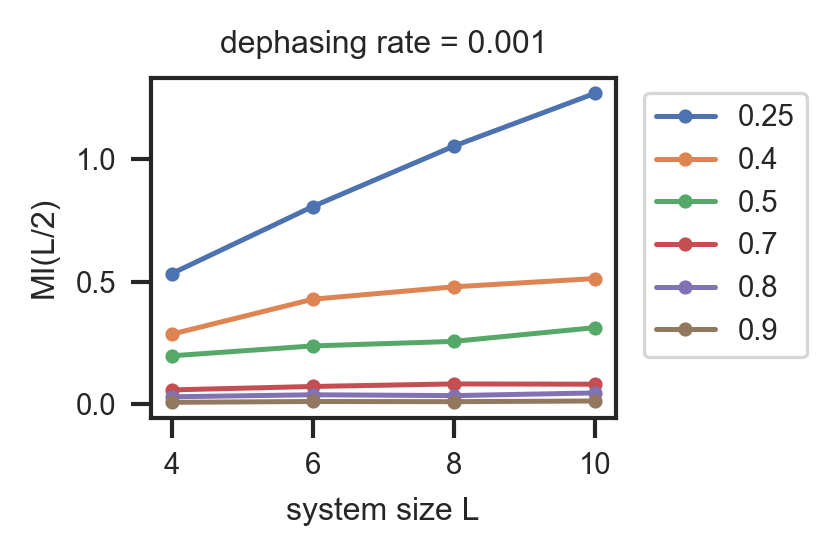

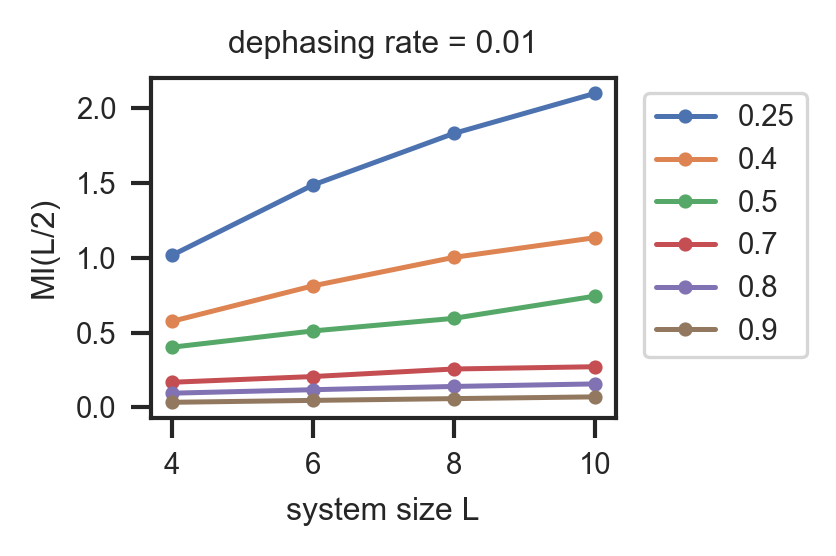

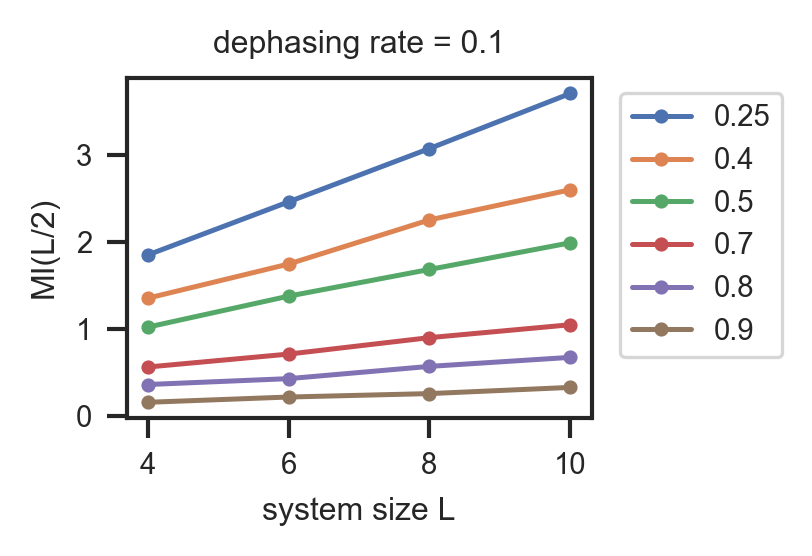

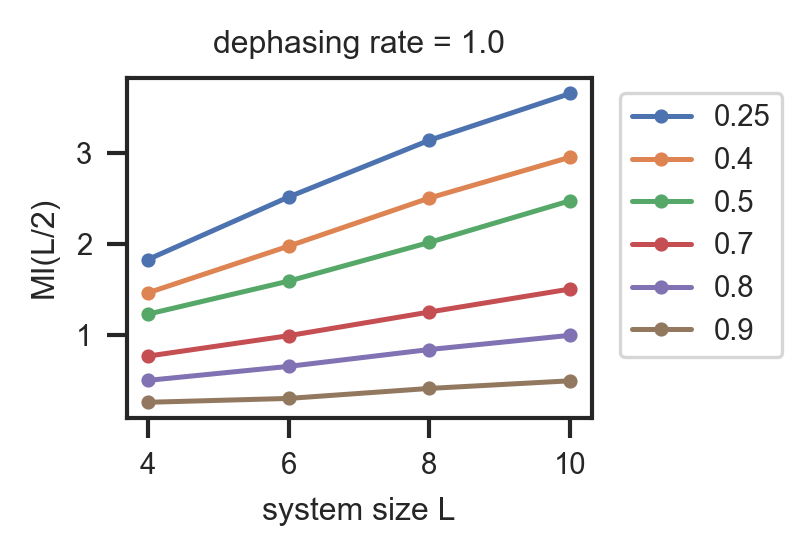

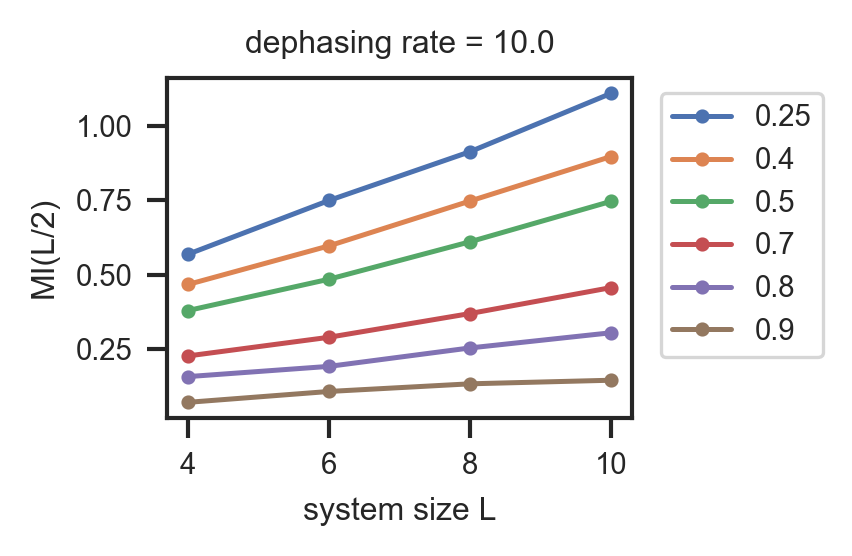

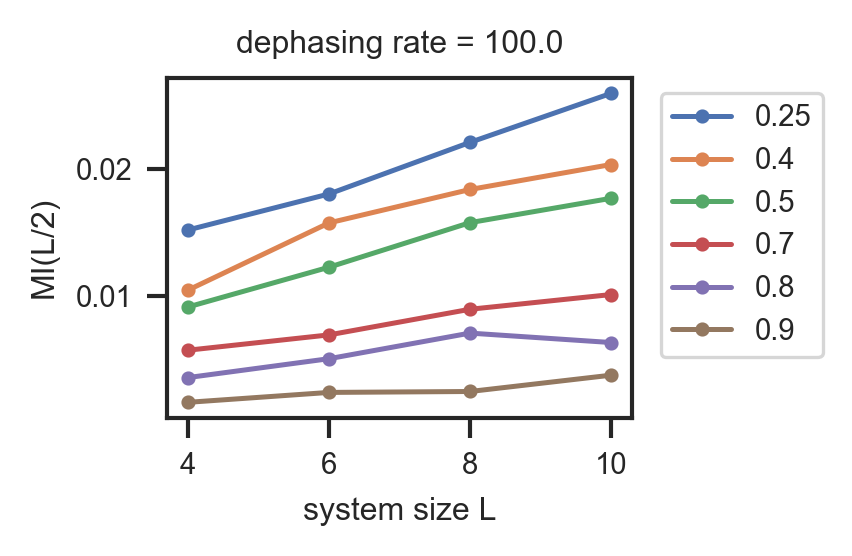

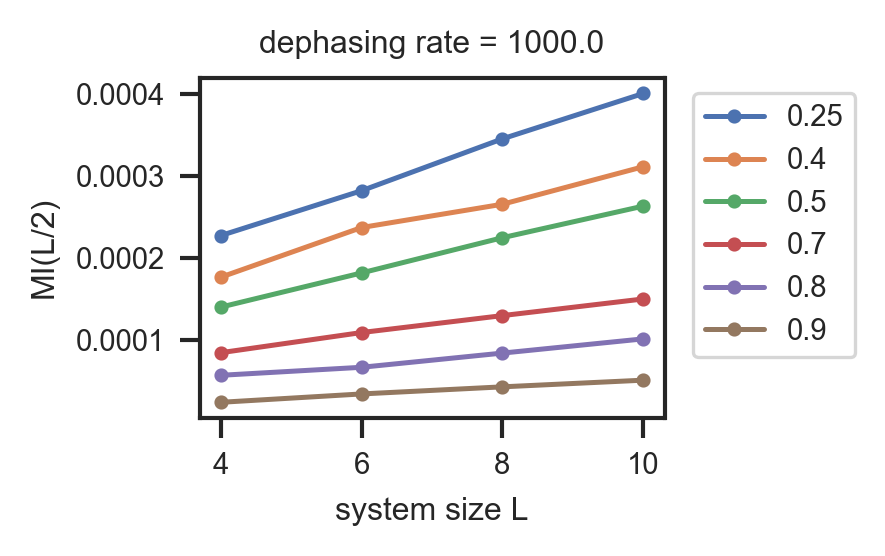

In [165]:
probList = [0.25, 0.4, 0.5, .7, 0.8, .9]

for rate in rateList:
    plt.figure()
    for prob in probList:
        plt.plot(np.array(NList), avgedMI_steady_1[rate][prob],'.-')
        plt.xlabel('system size L')
        plt.ylabel('MI(L/2)')
        plt.title('dephasing rate = ' + str(rate))
        plt.legend(probList,bbox_to_anchor= (1.03, 1))
   